In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import os

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
from google.colab import files
uploaded = files.upload()  # select your casting_data.zip

Saving casting_data.zip to casting_data.zip


In [3]:
import zipfile

with zipfile.ZipFile("casting_data.zip", "r") as zip_ref:
    zip_ref.extractall("casting_data")

print("Dataset extracted successfully")

Dataset extracted successfully


In [4]:
train_dir = "casting_data/casting_data/casting_data/train"
test_dir  = "casting_data/casting_data/casting_data/test"

for cls in ["ok_front", "def_front"]:
    print(f"train/{cls}: {len(os.listdir(os.path.join(train_dir, cls)))} images")
for cls in ["ok_front", "def_front"]:
    print(f"test/{cls}: {len(os.listdir(os.path.join(test_dir, cls)))} images")

train/ok_front: 2875 images
train/def_front: 3758 images
test/ok_front: 262 images
test/def_front: 453 images


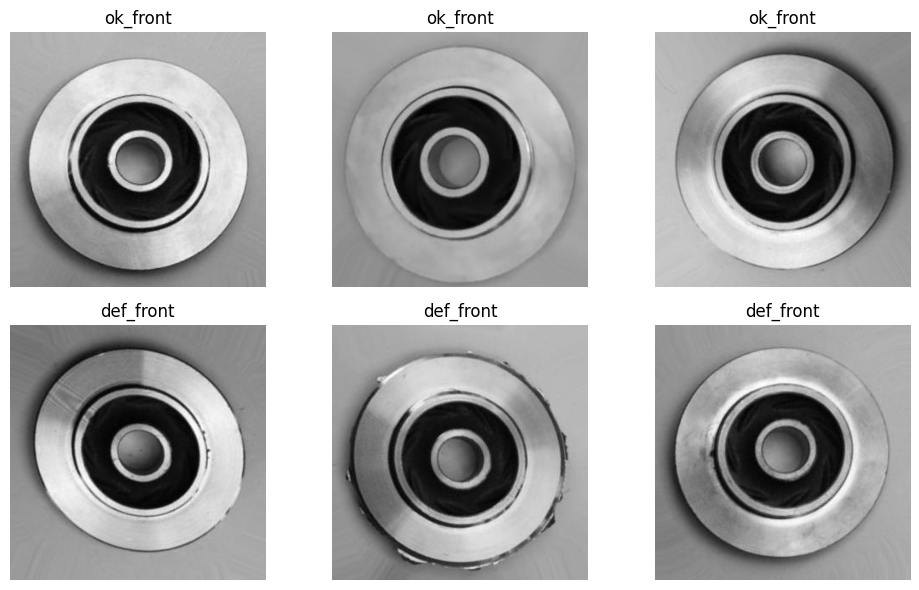

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))

for i, cls in enumerate(["ok_front", "def_front"]):
    sample_files = os.listdir(os.path.join(train_dir, cls))[:3]
    for j, fname in enumerate(sample_files):
        img = mpimg.imread(os.path.join(train_dir, cls, fname))
        axes[i, j].imshow(img)
        axes[i, j].set_title(cls)
        axes[i, j].axis("off")

plt.tight_layout()
plt.show()

In [6]:
image_size = (224, 224)
batch_size = 32
class_names = ["ok_front", "def_front"]  # ok_front=0, def_front=1

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, class_names=class_names, validation_split=0.20,
    subset="training", seed=42, image_size=image_size,
    batch_size=batch_size, label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, class_names=class_names, validation_split=0.20,
    subset="validation", seed=42, image_size=image_size,
    batch_size=batch_size, label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, class_names=class_names, image_size=image_size,
    batch_size=batch_size, label_mode="binary", shuffle=False
)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

print("Train batches:", len(train_dataset))
print("Validation batches:", len(validation_dataset))
print("Test batches:", len(test_dataset))

Train batches: 166
Validation batches: 42
Test batches: 23


In [8]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
    layers.RandomContrast(0.10)
], name="data_augmentation")

In [9]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, kernel_size=3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.40),

    layers.Dense(64, activation="relu"),
    layers.Dropout(0.30),

    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [11]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=0.000001
    ),
    tf.keras.callbacks.ModelCheckpoint(
        filepath="best_casting_defect_model.keras",
        monitor="val_loss", save_best_only=True
    )
]

In [12]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.5625 - loss: 0.6890 - precision: 0.5638 - recall: 0.9704 - val_accuracy: 0.5897 - val_loss: 0.6830 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 60ms/step - accuracy: 0.5608 - loss: 0.6851 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6767 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5790 - loss: 0.6719 - precision: 0.5740 - recall: 0.9667 - val_accuracy: 0.6026 - val_loss: 0.6374 - val_precision: 0.5992 - val_recall: 0.9847 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - accuracy: 0.6358 - loss: 0.6472 - precision: 0.6342 - recall: 0.8283 - val_accuracy: 0.5958 - val_loss: 0.6519 - val_precision: 0.7480 - val_recall: 0.4744 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 59ms/step - a

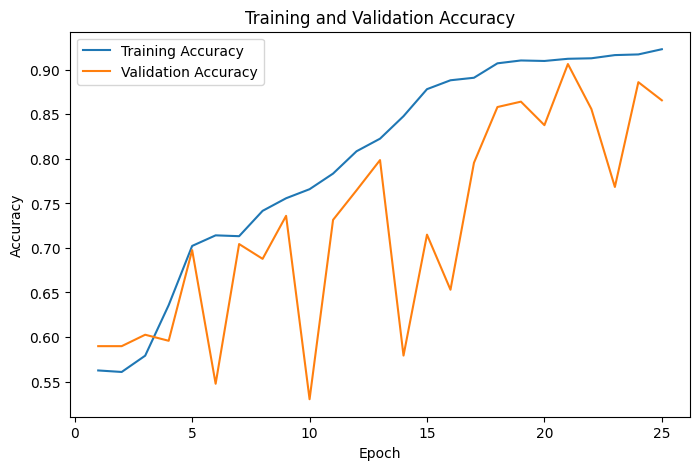

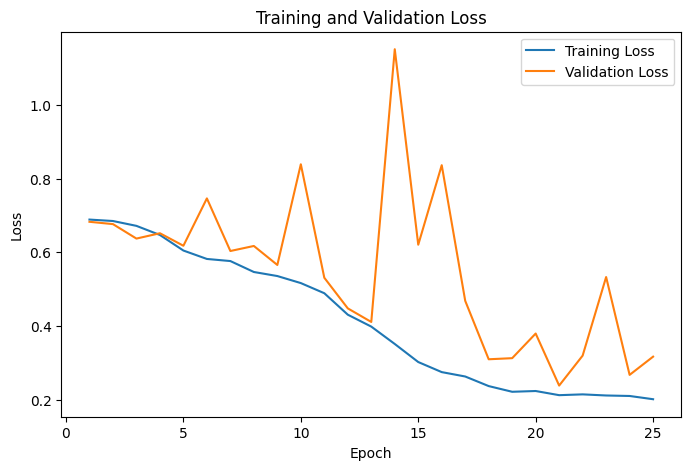

In [13]:
training_accuracy = history.history["accuracy"]
validation_accuracy = history.history["val_accuracy"]
training_loss = history.history["loss"]
validation_loss = history.history["val_loss"]

epochs_range = range(1, len(training_accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_accuracy, label="Training Accuracy")
plt.plot(epochs_range, validation_accuracy, label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, training_loss, label="Training Loss")
plt.plot(epochs_range, validation_loss, label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.show()

In [14]:
test_results = model.evaluate(test_dataset)
print("Test results [loss, accuracy, precision, recall]:", test_results)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step - accuracy: 0.9133 - loss: 0.2295 - precision: 0.9827 - recall: 0.8786
Test results [loss, accuracy, precision, recall]: [0.2295420616865158, 0.9132866859436035, 0.9827160239219666, 0.8785871863365173]


In [15]:
prediction_probabilities = model.predict(test_dataset)
predicted_labels = (prediction_probabilities.flatten() >= 0.5).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten() for images, labels in test_dataset
]).astype(int)

print(classification_report(
    actual_labels, predicted_labels,
    target_names=["Non-defective", "Defective"]
))

matrix = confusion_matrix(actual_labels, predicted_labels)
print("Confusion matrix:\n", matrix)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step
               precision    recall  f1-score   support

Non-defective       0.82      0.97      0.89       262
    Defective       0.98      0.88      0.93       453

     accuracy                           0.91       715
    macro avg       0.90      0.93      0.91       715
 weighted avg       0.92      0.91      0.91       715

Confusion matrix:
 [[255   7]
 [ 55 398]]


In [18]:
import os

test_def_dir = "casting_data/casting_data/casting_data/test/def_front"
sample_file = os.listdir(test_def_dir)[0]
print("Using file:", sample_file)

predict_product(
    os.path.join(test_def_dir, sample_file),
    model,
    threshold=0.50
)

Using file: new__0_1385.jpeg
Prediction: Defective
Defect probability: 99.35%
Recommended action: Send for manual inspection


In [19]:
test_ok_dir = "casting_data/casting_data/casting_data/test/ok_front"

samples = [
    (os.path.join(test_ok_dir, f), "Non-defective") for f in os.listdir(test_ok_dir)[:3]
] + [
    (os.path.join(test_def_dir, f), "Defective") for f in os.listdir(test_def_dir)[:2]
]

for path, actual in samples:
    print(f"--- Actual: {actual} ---")
    predict_product(path, model, threshold=0.50)
    print()

--- Actual: Non-defective ---
Prediction: Non-defective
Defect probability: 0.05%
Recommended action: Product may proceed

--- Actual: Non-defective ---
Prediction: Non-defective
Defect probability: 0.01%
Recommended action: Product may proceed

--- Actual: Non-defective ---
Prediction: Non-defective
Defect probability: 2.70%
Recommended action: Product may proceed

--- Actual: Defective ---
Prediction: Defective
Defect probability: 99.35%
Recommended action: Send for manual inspection

--- Actual: Defective ---
Prediction: Non-defective
Defect probability: 12.54%
Recommended action: Product may proceed



In [20]:
from google.colab import files
files.download("best_casting_defect_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
for t in [0.30, 0.40, 0.50, 0.60]:
    preds = (prediction_probabilities.flatten() >= t).astype(int)
    print(f"Threshold {t}:")
    print(classification_report(actual_labels, preds, target_names=["Non-defective", "Defective"]))

Threshold 0.3:
               precision    recall  f1-score   support

Non-defective       0.88      0.90      0.89       262
    Defective       0.94      0.93      0.94       453

     accuracy                           0.92       715
    macro avg       0.91      0.91      0.91       715
 weighted avg       0.92      0.92      0.92       715

Threshold 0.4:
               precision    recall  f1-score   support

Non-defective       0.86      0.92      0.89       262
    Defective       0.95      0.91      0.93       453

     accuracy                           0.91       715
    macro avg       0.90      0.92      0.91       715
 weighted avg       0.92      0.91      0.92       715

Threshold 0.5:
               precision    recall  f1-score   support

Non-defective       0.82      0.97      0.89       262
    Defective       0.98      0.88      0.93       453

     accuracy                           0.91       715
    macro avg       0.90      0.93      0.91       715
 weighted av